Import + get data initially ready for training + unlearning pipeline

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
statlog_german_credit_data = fetch_ucirepo(id=144) 
  
# data (as pandas dataframes) 
X = statlog_german_credit_data.data.features 
y = statlog_german_credit_data.data.targets 

def rename_german_credit_columns(df):
    column_mapping = {
        "Attribute1": "Status_of_existing_checking_account",
        "Attribute2": "Duration_in_month",
        "Attribute3": "Credit_history",
        "Attribute4": "Purpose",
        "Attribute5": "Credit_amount",
        "Attribute6": "Savings_account_bonds",
        "Attribute7": "Present_employment_since",
        "Attribute8": "Installment_rate_in_percentage_of_disposable_income",
        "Attribute9": "Personal_status_and_sex",
        "Attribute10": "Other_debtors_guarantors",
        "Attribute11": "Present_residence_since",
        "Attribute12": "Property",
        "Attribute13": "Age_in_years",
        "Attribute14": "Other_installment_plans",
        "Attribute15": "Housing",
        "Attribute16": "Number_of_existing_credits_at_this_bank",
        "Attribute17": "Job",
        "Attribute18": "Number_of_people_being_liable_to_provide_maintenance_for",
        "Attribute19": "Telephone",
        "Attribute20": "Foreign_worker"
    }

    return df.rename(columns=column_mapping)

df = rename_german_credit_columns(X)

categorical_cols = [
        "Status_of_existing_checking_account",
        "Credit_history",
        "Purpose",
        "Savings_account_bonds",
        "Present_employment_since",
        "Personal_status_and_sex",
        "Other_debtors_guarantors",
        "Property",
        "Other_installment_plans",
        "Housing",
        "Job",
        "Telephone",
        "Foreign_worker"
    ]

df_encoded = pd.get_dummies(
        df,
        columns=categorical_cols
)

y['class'] = (y['class'] - 1).astype(float)


In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd.forward_ad as fwAD
from torch.func import functional_call
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression as SklearnLR
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

--- Phase 1: Splitting Data ---
Features: 61
Total Train: 850 | (Retain: 765, Forget: 85)
Total Test (Unseen): 150

--- Phase 2: Initial Training ---
Epoch  20/1000 | Loss: 0.5792 | Accuracy: 70.9%
Epoch  40/1000 | Loss: 0.5574 | Accuracy: 71.4%
Epoch  60/1000 | Loss: 0.5440 | Accuracy: 71.8%
Epoch  80/1000 | Loss: 0.5338 | Accuracy: 72.5%
Epoch 100/1000 | Loss: 0.5256 | Accuracy: 72.8%
Epoch 120/1000 | Loss: 0.5190 | Accuracy: 74.0%
Epoch 140/1000 | Loss: 0.5134 | Accuracy: 74.1%
Epoch 160/1000 | Loss: 0.5086 | Accuracy: 73.9%
Epoch 180/1000 | Loss: 0.5045 | Accuracy: 74.6%
Epoch 200/1000 | Loss: 0.5010 | Accuracy: 74.6%
Epoch 220/1000 | Loss: 0.4979 | Accuracy: 74.5%
Epoch 240/1000 | Loss: 0.4951 | Accuracy: 75.1%
Epoch 260/1000 | Loss: 0.4927 | Accuracy: 75.2%
Epoch 280/1000 | Loss: 0.4905 | Accuracy: 75.6%
Epoch 300/1000 | Loss: 0.4885 | Accuracy: 75.6%
Epoch 320/1000 | Loss: 0.4868 | Accuracy: 75.8%
Epoch 340/1000 | Loss: 0.4852 | Accuracy: 75.9%
Epoch 360/1000 | Loss: 0.4837 | Ac

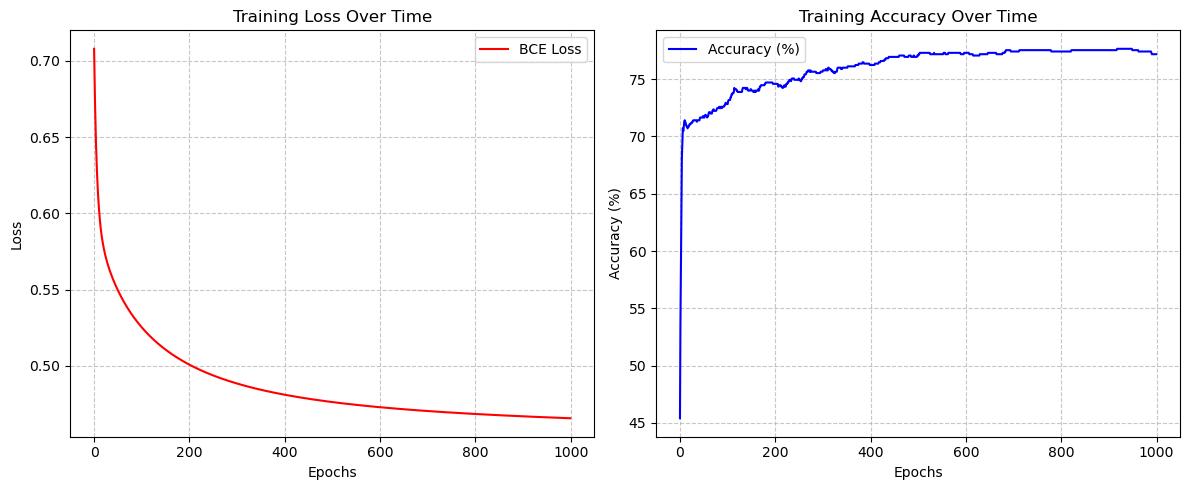


--- Phase 3: Extracting Forget Gradient ---
Forget gradient extracted successfully.

--- Phase 4: Calculating Unlearning Step ---
Unlearning step applied.

--- Phase 5: MIA Evaluation ---
MIA Score BEFORE Unlearning: 53.5%
MIA Score AFTER Unlearning:  52.9%

--- Phase 6: Model Accuracy ---
--- Original Model (w*) ---
Full Train Set: 77.2%
Forget Subset:  71.8%
Test Set:       81.3%

--- Unlearned Model (w_uf) ---
Full Train Set: 77.1% (Should remain high)
Forget Subset:  71.8%
Test Set:       81.3% (Should remain high)


In [21]:
# ==========================================
# Phase 1: Custom Data Splits & Tensor Conversion
# ==========================================
numerical_cols = [
    'Duration_in_month', 'Credit_amount', 
    'Installment_rate_in_percentage_of_disposable_income',
    'Present_residence_since', 'Age_in_years',
    'Number_of_existing_credits_at_this_bank',
    'Number_of_people_being_liable_to_provide_maintenance_for'
]

# Scale ONLY those columns directly inside the dataframe
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
print("--- Phase 1: Splitting Data ---")

# Extract underlying numpy arrays from pandas/your environment
# Force all columns to be floats before extracting the values
X_raw = df_encoded.astype(float).values
y_raw = y.astype(float).values

# 1. First Split: 85% Train / 15% Test
X_train_full, X_test_raw, y_train_full, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.15, random_state=42
)

# 2. Second Split: 90% Retain / 10% Forget (Extracting 10% from the Train set)
# Note: We still train the initial model on `X_train_full` so it actually learns the forget data first.
X_retain_raw, X_forget_raw, y_retain_raw, y_forget_raw = train_test_split(
    X_train_full, y_train_full, test_size=0.10, random_state=42
)

# Convert to PyTorch Tensors (forcing float32 and column-vector shape for labels)
X_train = torch.tensor(X_train_full, dtype=torch.float32)
y_train = torch.tensor(y_train_full, dtype=torch.float32).view(-1, 1)

X_forget = torch.tensor(X_forget_raw, dtype=torch.float32)
y_forget = torch.tensor(y_forget_raw, dtype=torch.float32).view(-1, 1)

X_test = torch.tensor(X_test_raw, dtype=torch.float32)
y_test = torch.tensor(y_test_raw, dtype=torch.float32).view(-1, 1)

input_dim = X_train.shape[1]
print(f"Features: {input_dim}")
print(f"Total Train: {len(X_train)} | (Retain: {len(X_retain_raw)}, Forget: {len(X_forget)})")
print(f"Total Test (Unseen): {len(X_test)}")


# ==========================================
# Phase 2: INITIAL TRAINING (w*) WITH LOGGING
# ==========================================
print("\n--- Phase 2: Initial Training ---")
class LogisticRegression(nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)
    def forward(self, x):
        return self.linear(x)

weight_decay_lambda = 0.0001 # 0.0005
learning_rate = 0.05 # 0.01
epochs = 1000 # 200

model = LogisticRegression(input_dim)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay_lambda)

# --- NEW: Tracking Arrays ---
train_losses = []
train_accuracies = []

model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Forward pass
    logits = model(X_train)
    loss = criterion(logits, y_train)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # --- NEW: Log Metrics ---
    train_losses.append(loss.item())
    
    # Calculate accuracy for this epoch without tracking gradients
    with torch.no_grad():
        predictions = (logits > 0).float()
        correct_guesses = (predictions == y_train).float().sum()
        accuracy = (correct_guesses / len(y_train)).item() * 100
        train_accuracies.append(accuracy)
        
    # Print an update every 20 epochs
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {loss.item():.4f} | Accuracy: {accuracy:.1f}%")

print(f"\nFinal Training Loss: {train_losses[-1]:.4f}")
print(f"Final Training Accuracy: {train_accuracies[-1]:.1f}%")

# ==========================================
# Phase 2.5: PLOT LEARNING CURVES
# ==========================================
plt.figure(figsize=(12, 5))

# Plot 1: Loss over time
plt.subplot(1, 2, 1)
plt.plot(train_losses, color='red', label='BCE Loss')
plt.title('Training Loss Over Time')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: Accuracy over time
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, color='blue', label='Accuracy (%)')
plt.title('Training Accuracy Over Time')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

# ==========================================
# Phase 3: EXTRACT FORGET GRADIENT (\nabla_f)
# ==========================================
print("\n--- Phase 3: Extracting Forget Gradient ---")
model.eval() 
model.zero_grad() 

# Calculate the gradient specifically on the 10% forget subset
forget_loss = criterion(model(X_forget), y_forget)
forget_loss.backward()

nabla_f = []
for param in model.parameters():
    # True gradient includes the BCE error + the L2 penalty derivative
    total_grad = param.grad + (weight_decay_lambda * param.data)
    nabla_f.append(total_grad.detach().clone())
print("Forget gradient extracted successfully.")


# ==========================================
# Phase 4: THE UNLEARNING ENGINE (Solving H^{-1} * \nabla_f)
# ==========================================
print("\n--- Phase 4: Calculating Unlearning Step ---")
v_param = {name: nn.Parameter(torch.zeros_like(param)) for name, param in model.named_parameters()}
v_optimizer = optim.SGD(v_param.values(), lr=0.01)

def l2_regularization(params):
    return sum(p.norm(2)**2 for p in params) / 2

def gradient_vector_inner_product(grads, vector_values):
    return sum(torch.sum(g * v) for g, v in zip(grads, vector_values))

def jvp_norm_loss(arch, primals, tangents, inp):
    dual_params = {}
    with fwAD.dual_level():
        for name, p in primals.items():
            dual_params[name] = fwAD.make_dual(p, tangents[name])
        out = functional_call(arch, dual_params, inp)
        jvp = fwAD.unpack_dual(out).tangent
    return (torch.norm(jvp) ** 2) / inp.shape[0]

for epoch in range(150):
    if (epoch + 1) in [30, 60, 90, 120]:
        v_optimizer.param_groups[0]['lr'] *= 0.5
    v_optimizer.zero_grad()

    primals = dict(model.named_parameters())
    # Source-Free assumption: using X_forget to estimate curvature
    jvp_loss = 0.5 * jvp_norm_loss(model, primals, v_param, X_forget)
    inner_product_loss = gradient_vector_inner_product(nabla_f, v_param.values())
    reg_loss = 0.5 * weight_decay_lambda * l2_regularization(v_param.values())

    loss = jvp_loss + reg_loss - inner_product_loss
    loss.backward()
    v_optimizer.step()

# Apply the step to a new copy of the model
unlearned_model = LogisticRegression(input_dim)
unlearned_model.load_state_dict(model.state_dict())
with torch.no_grad():
    for (name, param), v_step in zip(unlearned_model.named_parameters(), v_param.values()):
        param.copy_(param + v_step)
print("Unlearning step applied.")


# ==========================================
# Phase 5: EVALUATION (MIA SCORE)
# ==========================================
print("\n--- Phase 5: MIA Evaluation ---")
def calculate_mia_score(eval_model, forget_x, forget_y, test_x, test_y):
    eval_model.eval()
    with torch.no_grad():
        bce_no_reduce = nn.BCEWithLogitsLoss(reduction='none')
        forget_losses = bce_no_reduce(eval_model(forget_x), forget_y).numpy()
        test_losses = bce_no_reduce(eval_model(test_x), test_y).numpy()

    # Balance the attacker dataset by limiting the test_losses to the size of forget_losses
    min_len = min(len(forget_losses), len(test_losses))
    forget_losses = forget_losses[:min_len]
    test_losses = test_losses[:min_len]

    X_attack = np.concatenate([forget_losses, test_losses]).reshape(-1, 1)
    y_attack = np.concatenate([np.ones(min_len), np.zeros(min_len)])

    attacker = SklearnLR()
    attacker.fit(X_attack, y_attack)
    return accuracy_score(y_attack, attacker.predict(X_attack)) * 100

mia_before = calculate_mia_score(model, X_forget, y_forget, X_test, y_test)
mia_after = calculate_mia_score(unlearned_model, X_forget, y_forget, X_test, y_test)

print(f"MIA Score BEFORE Unlearning: {mia_before:.1f}%")
print(f"MIA Score AFTER Unlearning:  {mia_after:.1f}%")

# ==========================================
# Phase 6: CLASSIFICATION ACCURACY
# ==========================================
print("\n--- Phase 6: Model Accuracy ---")

def calculate_accuracy(eval_model, X, y):
    eval_model.eval()
    with torch.no_grad():
        logits = eval_model(X)
        predictions = (logits > 0).float()
        correct_guesses = (predictions == y).float().sum()
        accuracy = (correct_guesses / len(y)).item() * 100
    return accuracy

# 1. Evaluate Original Model
orig_train_acc = calculate_accuracy(model, X_train, y_train)
orig_forget_acc = calculate_accuracy(model, X_forget, y_forget)
orig_test_acc = calculate_accuracy(model, X_test, y_test)

# 2. Evaluate Unlearned Model
unl_train_acc = calculate_accuracy(unlearned_model, X_train, y_train)
unl_forget_acc = calculate_accuracy(unlearned_model, X_forget, y_forget)
unl_test_acc = calculate_accuracy(unlearned_model, X_test, y_test)

print("--- Original Model (w*) ---")
print(f"Full Train Set: {orig_train_acc:.1f}%")
print(f"Forget Subset:  {orig_forget_acc:.1f}%")
print(f"Test Set:       {orig_test_acc:.1f}%")

print("\n--- Unlearned Model (w_uf) ---")
print(f"Full Train Set: {unl_train_acc:.1f}% (Should remain high)")
print(f"Forget Subset:  {unl_forget_acc:.1f}%")
print(f"Test Set:       {unl_test_acc:.1f}% (Should remain high)")

In [12]:
df_encoded.columns

Index(['Duration_in_month', 'Credit_amount',
       'Installment_rate_in_percentage_of_disposable_income',
       'Present_residence_since', 'Age_in_years',
       'Number_of_existing_credits_at_this_bank',
       'Number_of_people_being_liable_to_provide_maintenance_for',
       'Status_of_existing_checking_account_A11',
       'Status_of_existing_checking_account_A12',
       'Status_of_existing_checking_account_A13',
       'Status_of_existing_checking_account_A14', 'Credit_history_A30',
       'Credit_history_A31', 'Credit_history_A32', 'Credit_history_A33',
       'Credit_history_A34', 'Purpose_A40', 'Purpose_A41', 'Purpose_A410',
       'Purpose_A42', 'Purpose_A43', 'Purpose_A44', 'Purpose_A45',
       'Purpose_A46', 'Purpose_A48', 'Purpose_A49',
       'Savings_account_bonds_A61', 'Savings_account_bonds_A62',
       'Savings_account_bonds_A63', 'Savings_account_bonds_A64',
       'Savings_account_bonds_A65', 'Present_employment_since_A71',
       'Present_employment_since_A72', 

NameError: name 'mia_before' is not defined

In [29]:
type(y['class'][0])

numpy.float64